In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,accuracy_score,roc_curve,auc
from sklearn.model_selection import train_test_split


In [80]:
df = pd.read_csv("Titanic_Train.csv")

In [81]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [82]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [83]:
df.shape

(891, 12)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [85]:
df['Sex'] = df['Sex'].map({'male':1,'female':0})

In [86]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


In [87]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [88]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [89]:
df= df.dropna(subset=['Embarked'])

In [90]:
df['Embarked']= df['Embarked'].map({"S":0,"C":1,"Q":2})

In [129]:
x = df.drop(columns=['Survived','PassengerId','Name','Parch','Ticket','Cabin'])
y=df['Survived']

In [130]:
x.head()

,Pclass,Sex,Age,SibSp,Fare,Embarked
0,3,1,22.0,1,7.2500,0
1,1,0,38.0,1,71.2833,1
2,3,0,26.0,0,7.9250,0
3,1,0,35.0,1,53.1000,0
4,3,1,35.0,0,8.0500,0


In [131]:
corr = x.corr()

<Axes: >

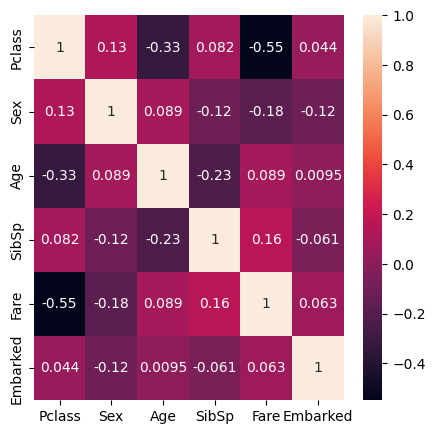

In [132]:
plt.figure(figsize=(5,5))
sns.heatmap(corr,annot=True)

In [133]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [154]:
model = RandomForestClassifier(n_estimators=100)
model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [155]:
y_pred = model.predict(x_test)

In [156]:
acc = accuracy_score(y_test,y_pred)
cr = classification_report(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print(cr)
print(cm)
print(acc)

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       109
           1       0.76      0.78      0.77        69

    accuracy                           0.82       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.82      0.82      0.82       178

[[92 17]
 [15 54]]
0.8202247191011236


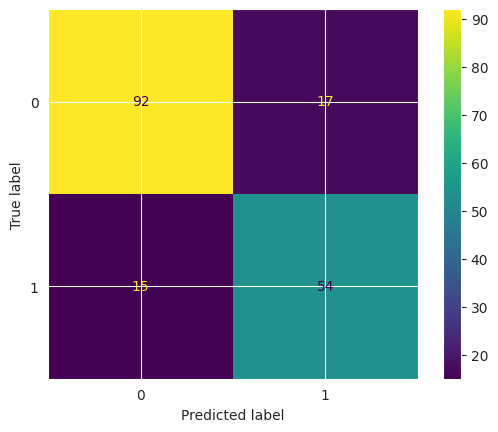

In [168]:
ConfusionMatrixDisplay(cm).plot()

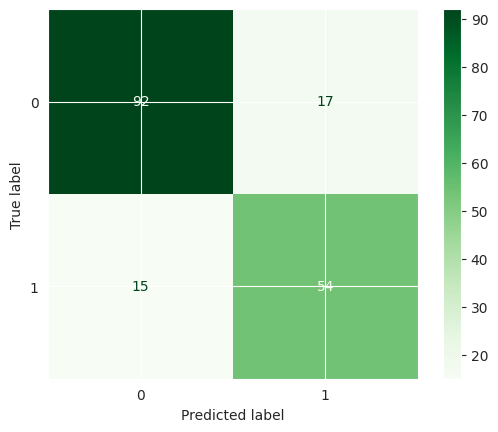

In [167]:
cmd = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
cmd.plot(cmap='Greens')
plt.show()

In [159]:
x.head()

,Pclass,Sex,Age,SibSp,Fare,Embarked
0,3,1,22.0,1,7.2500,0
1,1,0,38.0,1,71.2833,1
2,3,0,26.0,0,7.9250,0
3,1,0,35.0,1,53.1000,0
4,3,1,35.0,0,8.0500,0


In [160]:

feature_importance = model.feature_importances_
features = x.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance}).sort_values('Importance', ascending=False)
print(importance_df)
print("\nTop 3 Features Contributing to Survival Prediction:")
print(importance_df.head(3))

    Feature  Importance
4      Fare    0.288537
1       Sex    0.260781
2       Age    0.260570
0    Pclass    0.093390
3     SibSp    0.058924
5  Embarked    0.037800

Top 3 Features Contributing to Survival Prediction:
  Feature  Importance
4    Fare    0.288537
1     Sex    0.260781
2     Age    0.260570


/tmp/ipykernel_16061/3584149835.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


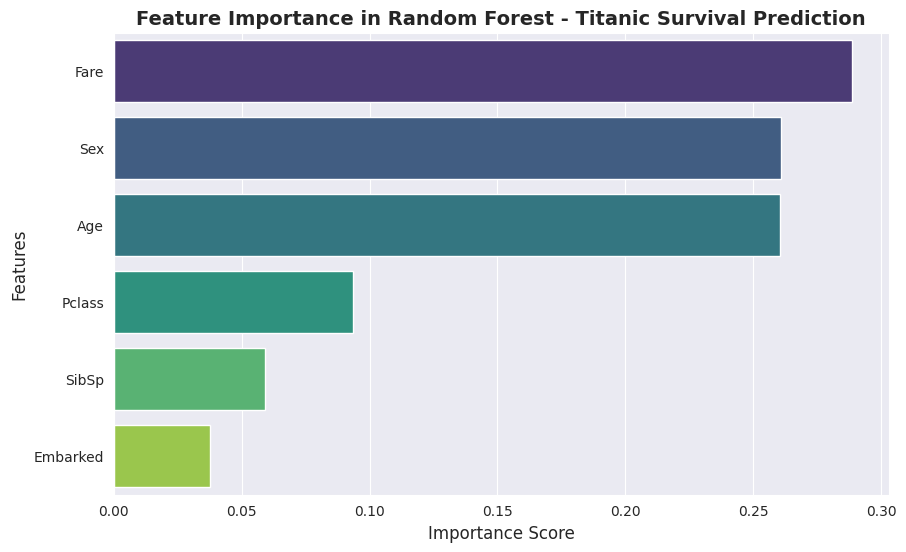

In [161]:
# Plot Feature Importance using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance in Random Forest - Titanic Survival Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

In [121]:
# # Get probability predictions for ROC curve
# y_pred_proba = model.predict_proba(x_test)[:, 1]

# # Calculate ROC curve values
# fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
# roc_auc = auc(fpr, tpr)

# print(f"AUC Score: {roc_auc:.4f}")
# print(f"\nAUC Interpretation:")
# print(f"- AUC = {roc_auc:.2%}")
# print(f"- The model has a {roc_auc:.2%} probability of correctly distinguishing between survivors and non-survivors")
# print(f"\nAUC Scale:")
# print(f"- 0.90-1.00: Excellent discrimination")
# print(f"- 0.80-0.90: Good discrimination")
# print(f"- 0.70-0.80: Fair discrimination")
# print(f"- 0.60-0.70: Poor discrimination")
# print(f"- 0.50-0.60: Very poor discrimination")
# print(f"- 0.50: No discrimination (random guessing)")

AUC Score: 1.0000

AUC Interpretation:
- AUC = 100.00%
- The model has a 100.00% probability of correctly distinguishing between survivors and non-survivors

AUC Scale:
- 0.90-1.00: Excellent discrimination
- 0.80-0.90: Good discrimination
- 0.70-0.80: Fair discrimination
- 0.60-0.70: Poor discrimination
- 0.50-0.60: Very poor discrimination
- 0.50: No discrimination (random guessing)


In [162]:
y_pred_proba = model.predict_proba(x_test)[:, 1]

fpr,tpr,thresholds = roc_curve(y_test,y_pred_proba)

roc = auc(fpr,tpr)

print(roc*100,"%")

85.20143597925808 %


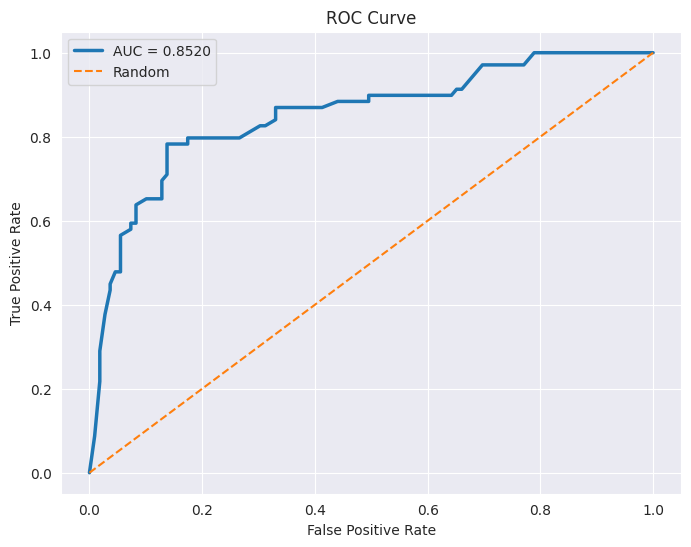

In [163]:
# Plot ROC Curve using Matplotlib and Seaborn styling

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2.5, label=f'AUC = {roc:.4f}')
plt.plot([0, 1], [0, 1], '--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

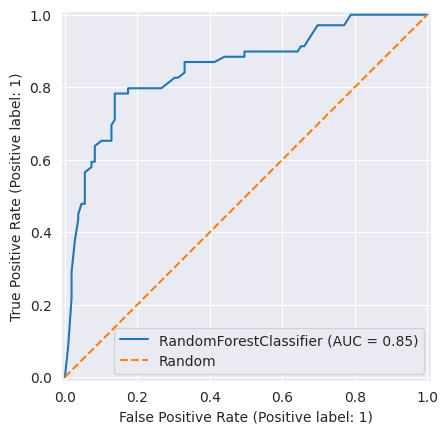

In [166]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, x_test, y_test)
plt.plot([0, 1], [0, 1], '--', label='Random')
plt.legend()
plt.show()